In [11]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [12]:
load_dotenv()

model = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

In [13]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

# calculate strike rate, balls per boundary etc
    sr: float
    bpb: float
    boundary_percent: float
    summary: str


In [14]:
def cal_sr(state: BatsmanState):

    sr = (state['runs']/ state['balls'])/ 100

    state['sr'] = sr
    return state


In [15]:
def cal_bpb(state: BatsmanState):

    bpb = state['balls']/ state['fours'] + state['sixes']

    state['bpb'] = bpb
    return state

In [16]:
def cal_bp(state: BatsmanState):

    bp = (((state['fours'] * 4) + (state['sixes'] * 6))/ state['runs']) * 100

    state['boundary_percent'] = bp
    return state

In [17]:
def summary(state: BatsmanState):

    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls per boundary - {state['bpb']} \n
    Boundary Percent - {state['boundary_percent']}
    """

    state['summary'] = summary
    return state

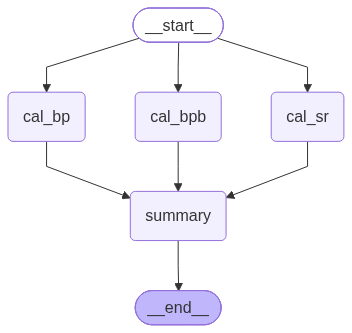

In [18]:
graph = StateGraph(BatsmanState)

# nodes
graph.add_node('cal_sr', cal_sr)
graph.add_node('cal_bpb', cal_bpb)
graph.add_node('cal_bp', cal_bp)
graph.add_node('summary', summary)

# edges
graph.add_edge(START, 'cal_sr')
graph.add_edge(START, 'cal_bpb')
graph.add_edge(START, 'cal_bp')

graph.add_edge('cal_sr', 'summary')
graph.add_edge('cal_bpb', 'summary')        
graph.add_edge('cal_bp', 'summary') 

graph.add_edge('summary', END)

workflow = graph.compile()

workflow
      